# 05 - Model Evaluation & Reports

Evaluate the **shipped** model (`models/vegetable_cnn.h5`) on the held-out test split.

`src/evaluate.py` runs a single deterministic pass and writes everything under
`reports/`: confusion matrix, per-class metrics and test-loss figures. This
notebook re-runs it and displays the summaries inline.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from IPython.display import display

from src.config import FIGURES_DIR, METRICS_DIR  # noqa: E402
from src.evaluate import evaluate_model  # noqa: E402

result = evaluate_model()
m = result["metrics"]
print(f"Test accuracy : {m['test_accuracy'] * 100:.2f}%   (manual: {m['manual_accuracy'] * 100:.2f}%)")
print(f"Test loss     : {m['test_loss']:.4f}")
print(f"Misclassified : {m['misclassified']} / {m['n_samples']}")
print(f"Input size    : {m['input_size'][0]} x {m['input_size'][1]}")


I0000 00:00:1790237129.848631 1663731 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790237129.966833 1663731 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790237135.717307 1663731 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Loading model from /mnt/hdd/projects/Vegetables-Classification/models/vegetable_cnn.h5 ...


E0000 00:00:1790237138.477168 1663731 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded.
Found 3000 files belonging to 15 classes.


Found 3000 files belonging to 15 classes.


/mnt/hdd/projects/Vegetables-Classification/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy : 98.43%   (manual: 98.43%)
Test loss     : 0.0756
Misclassified : 47 / 3000
Input size    : 150 x 150


## Per-class accuracy

In [2]:

display(result["per_class"])


,class,accuracy,correct,total
0,Bean,0.985,197,200
1,Bitter_Gourd,0.990,198,200
2,Bottle_Gourd,0.995,199,200
3,Brinjal,0.995,199,200
4,Broccoli,0.975,195,200
5,Cabbage,0.970,194,200
6,Capsicum,0.990,198,200
7,Carrot,1.000,200,200
8,Cauliflower,0.965,193,200
9,Cucumber,1.000,200,200


## Classification report (precision / recall / F1 / support)

In [3]:

display(result["report"])


,precision,recall,f1-score,support
Bean,0.980100,0.985000,0.982544,200.000000
Bitter_Gourd,0.951923,0.990000,0.970588,200.000000
Bottle_Gourd,0.995000,0.995000,0.995000,200.000000
Brinjal,0.970732,0.995000,0.982716,200.000000
Broccoli,0.975000,0.975000,0.975000,200.000000
Cabbage,0.974874,0.970000,0.972431,200.000000
Capsicum,0.985075,0.990000,0.987531,200.000000
Carrot,1.000000,1.000000,1.000000,200.000000
Cauliflower,0.994845,0.965000,0.979695,200.000000
Cucumber,0.995025,1.000000,0.997506,200.000000


## Figures saved to `reports/figures/`

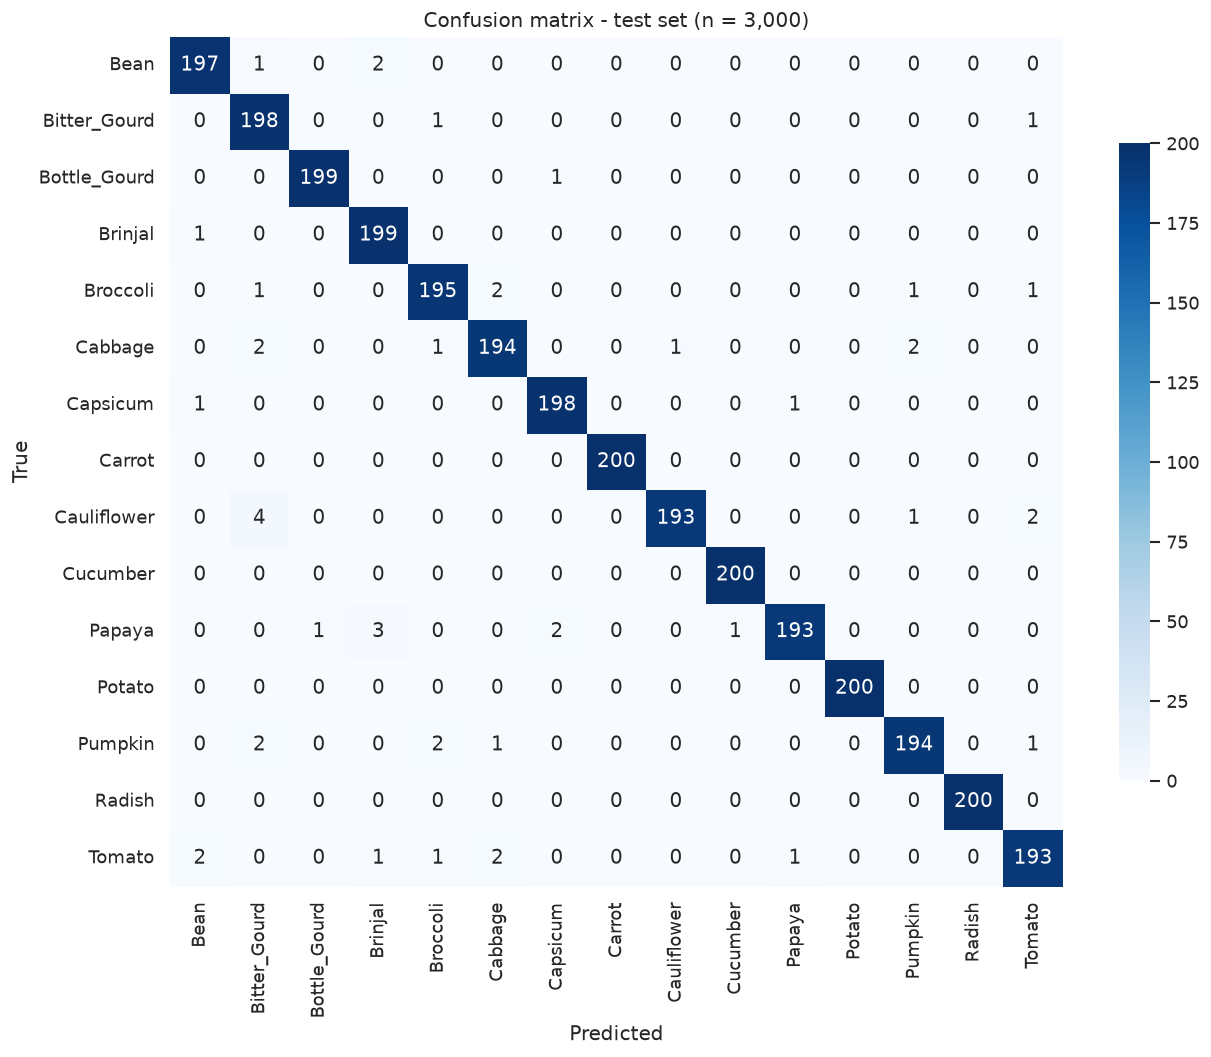

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/confusion_matrix.png


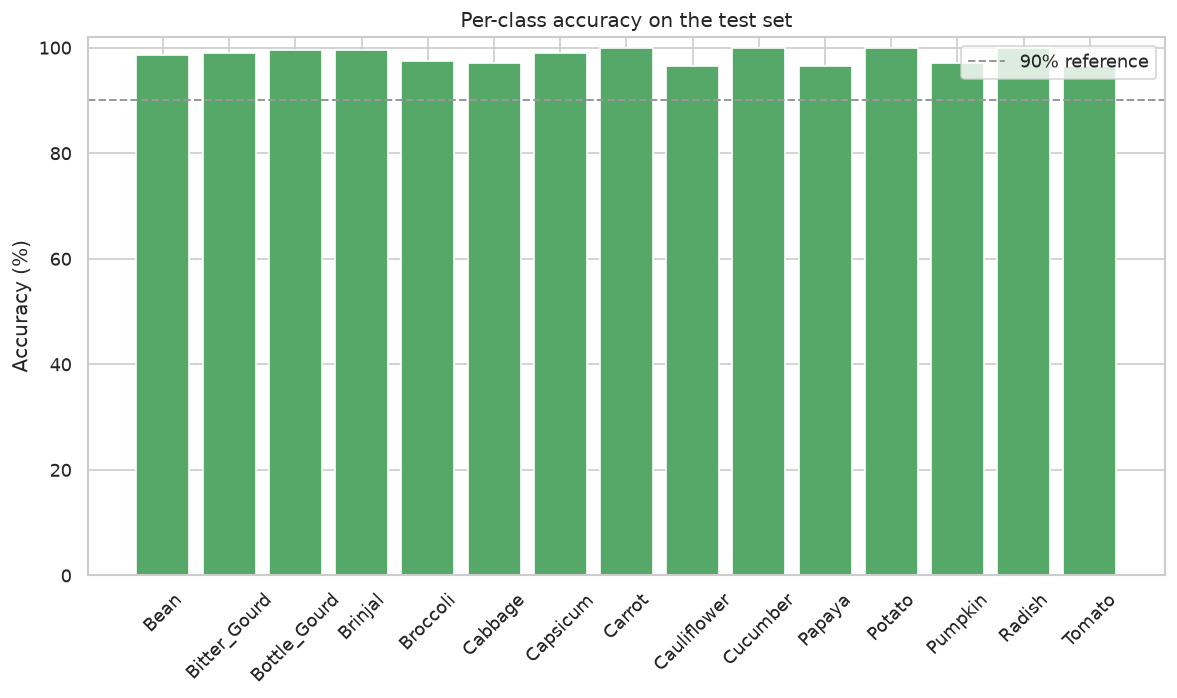

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/per_class_accuracy.png


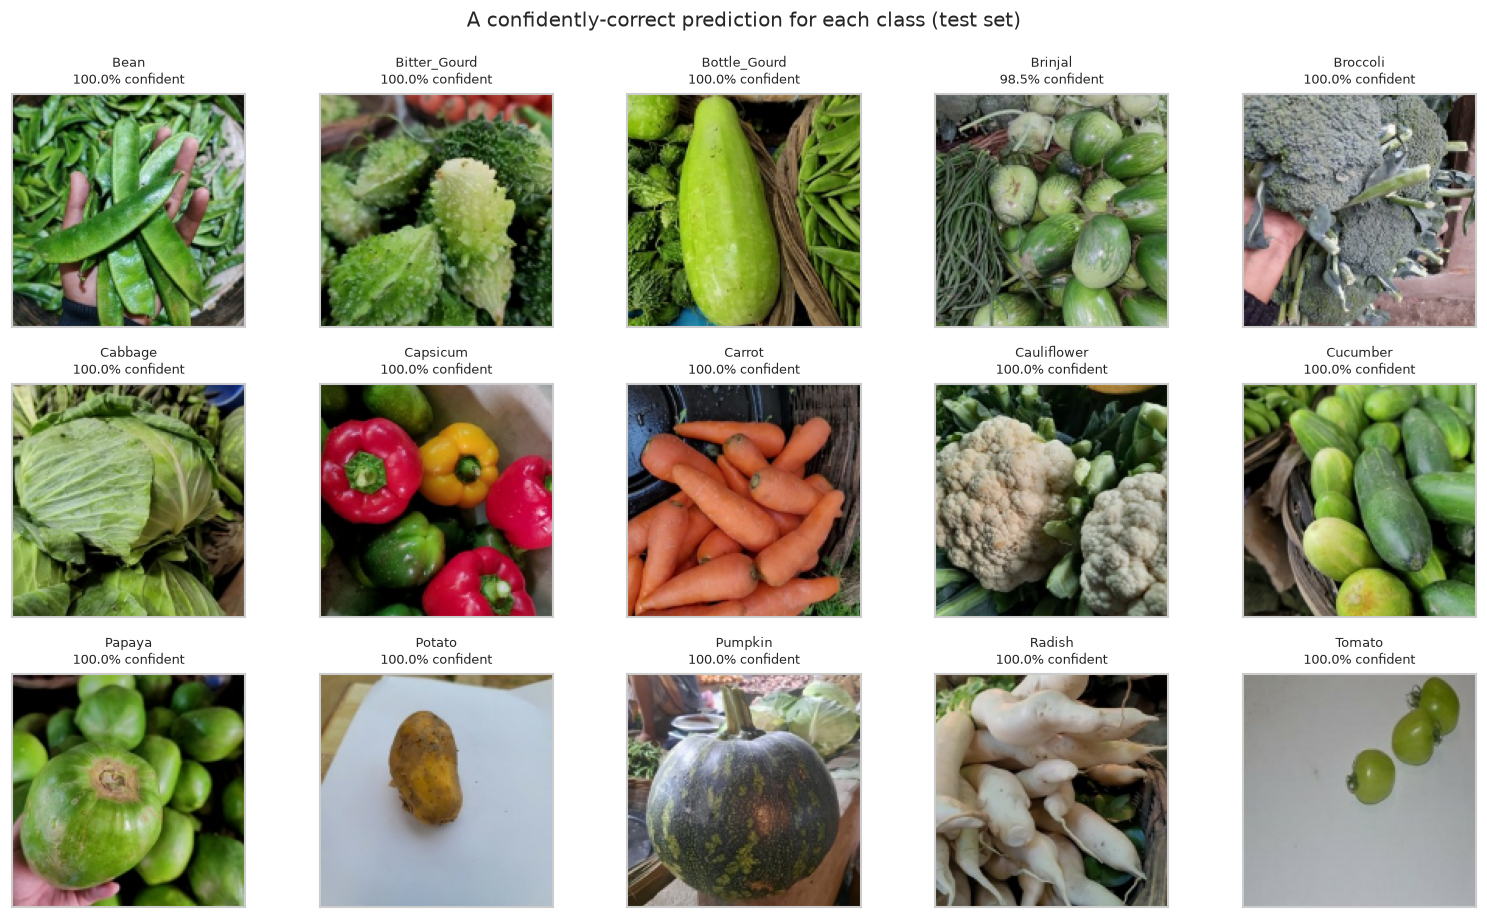

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/sample_predictions.png


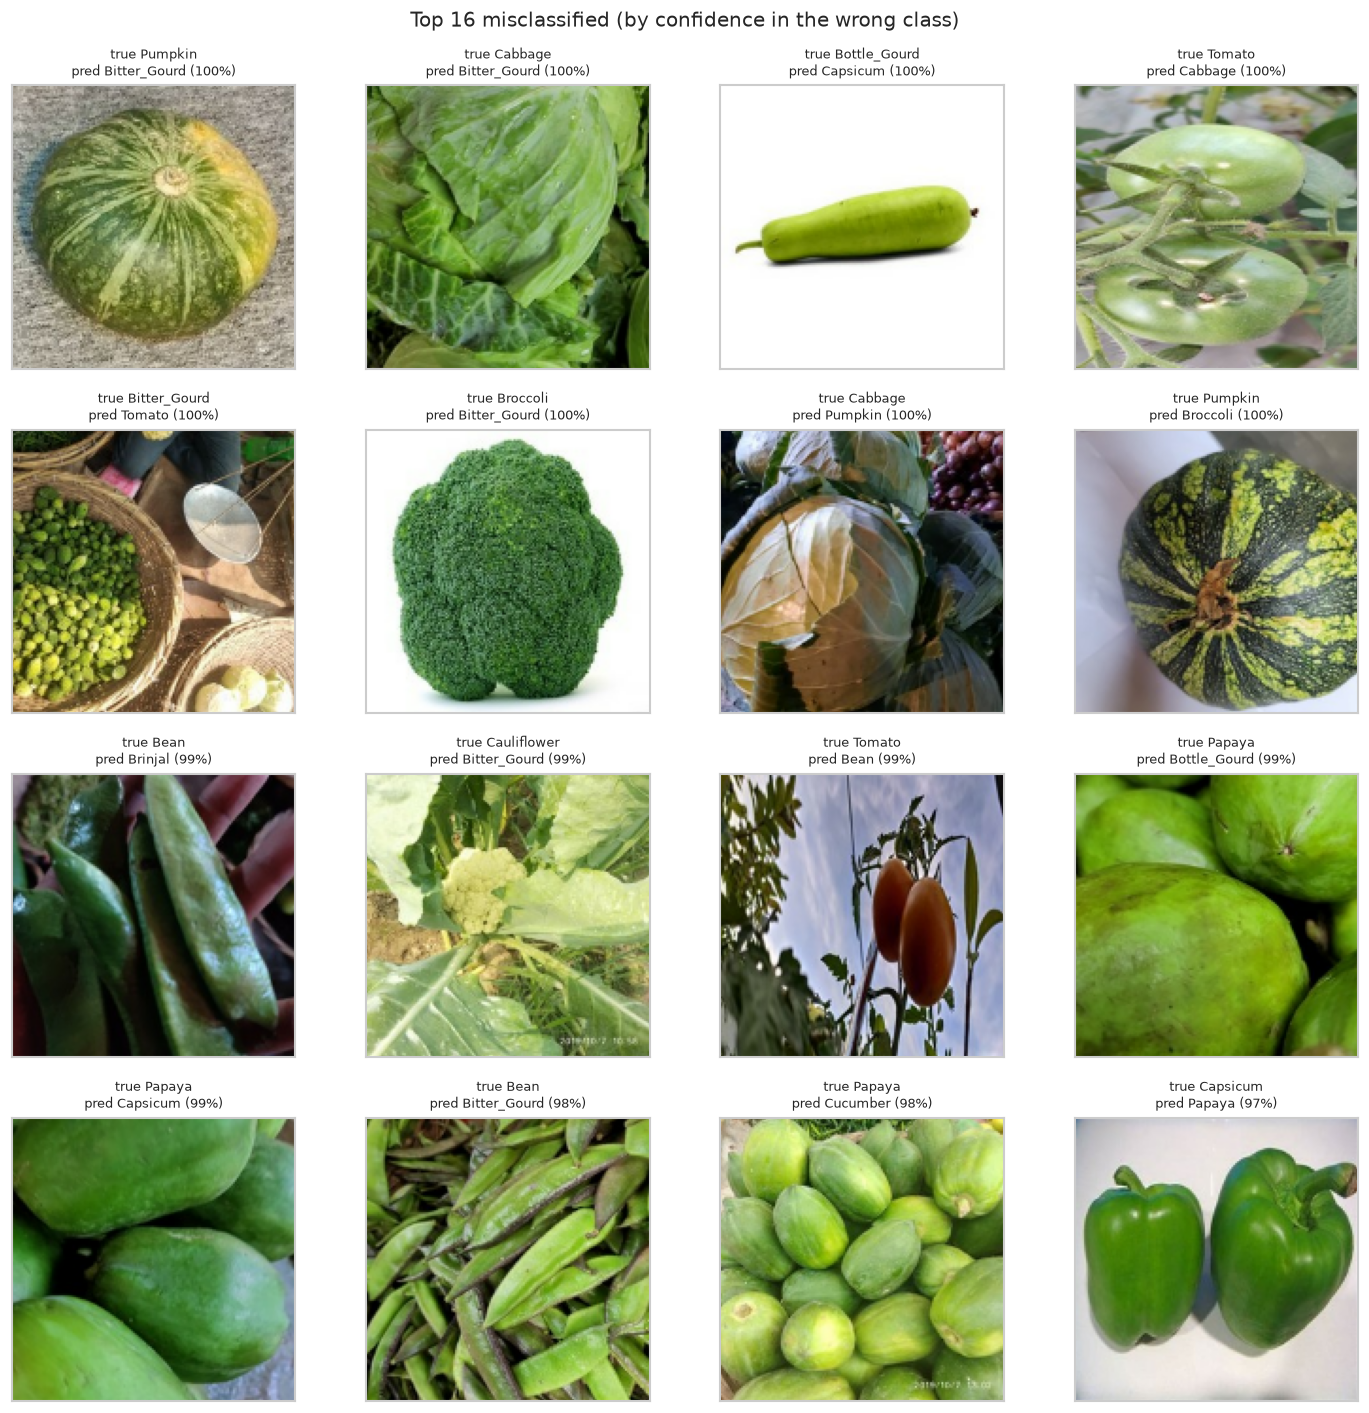

saved -> /mnt/hdd/projects/Vegetables-Classification/reports/figures/misclassified_samples.png


In [4]:

from IPython.display import Image as IPImage

figures = [
    "confusion_matrix.png",
    "per_class_accuracy.png",
    "sample_predictions.png",
    "misclassified_samples.png",
]
for name in figures:
    p = FIGURES_DIR / name
    display(IPImage(filename=str(p), width=620 if "confusion" not in name else 680))
    print(f"saved -> {p}")


## Summary
- The evaluation confirms the model performs at **~98% accuracy** on the 3,000-image test set.
- CSV metrics are under `reports/metrics/` and are rendered in the **Model Report** tab of the Streamlit app.